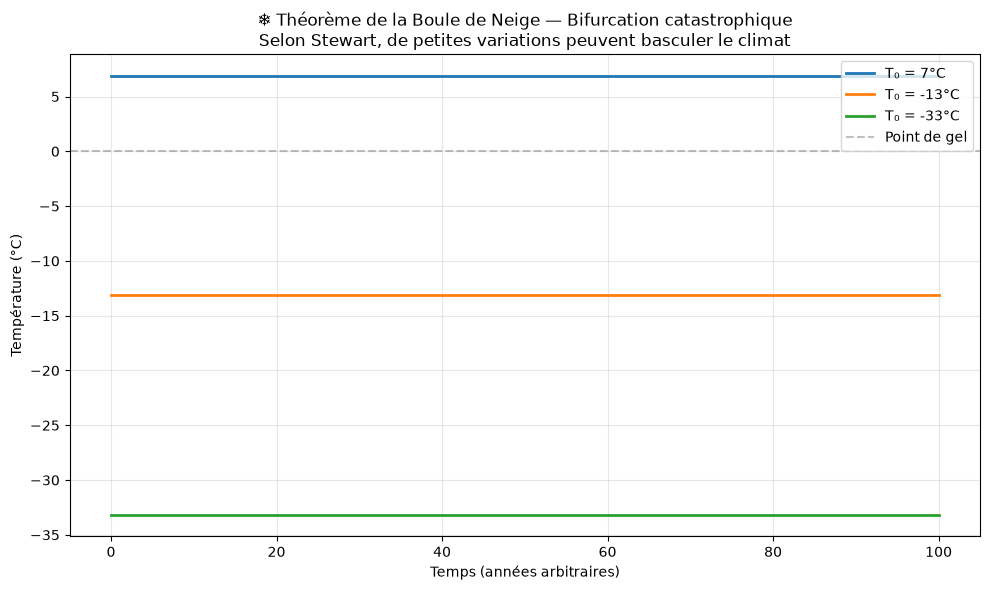

💡 Stewart montre que le système climatique a plusieurs équilibres stables.
   Une petite perturbation peut nous envoyer vers un 'Snowball Earth' !


In [2]:
from scipy.integrate import odeint

import matplotlib.pyplot as plt
import numpy as np

def albedo_feedback(T, t, S0=1361, sigma=5.67e-8, epsilon=0.6):
    """Modèle simplifié de Stewart : équilibre température-albédo"""
    # Albédo dépend de la température (glace = plus réfléchissante)
    albedo = 0.3 + 0.4 * (1 / (1 + np.exp((T - 273) / 5)))
    
    # Bilan radiatif
    absorbed = S0 * (1 - albedo) / 4
    emitted = epsilon * sigma * T**4
    
    dTdt = (absorbed - emitted) / (4e6)  # Capacité thermique simplifiée
    return dTdt

# Simulation de bifurcation
t = np.linspace(0, 100, 1000)
T0_values = [280, 260, 240]  # Conditions initiales différentes

fig, ax = plt.subplots(figsize=(10, 6))
for T0 in T0_values:
    T = odeint(albedo_feedback, T0, t)
    ax.plot(t, T - 273.15, label=f'T₀ = {T0-273.15:.0f}°C', linewidth=2)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Point de gel')
ax.set_xlabel("Temps (années arbitraires)")
ax.set_ylabel("Température (°C)")
ax.set_title("❄️ Théorème de la Boule de Neige — Bifurcation catastrophique\n"
             "Selon Stewart, de petites variations peuvent basculer le climat")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Stewart montre que le système climatique a plusieurs équilibres stables.")
print("   Une petite perturbation peut nous envoyer vers un 'Snowball Earth' !")